# 4.2k — Détection SOTA : le renversement — le camouflage adversarial contre YOLO

[← Série 04-Vision](README.md) | [← 4.2j — LibreYOLO](4.2j-Detection-SOTA-LibreYOLO.ipynb) | [4.2c — AnchorNet from scratch](4.2c-Detection-Anchor-From-Scratch.ipynb) | [4.6c — Du patch au vêtement](4.6c-Detection-Dazzle-Garment-StyleTransfer.ipynb)

Depuis 4.2c, la lignée a construit, entraîné, benchmarké et éprouvé YOLO — anchor, anchor-free,
focal loss, torchvision, ultralytics, le banc 4.2h, les scènes difficiles 4.2i, l'écosystème
libre 4.2j. Ce carnet opère le **renversement final** : après avoir appris comment un détecteur
**voit**, on apprend à **lui échapper**. Un motif optimisé — l'équivalent digital d'un t-shirt
imprimé — collé sur le torse d'un piéton fait chuter sa détection, **pendant que les autres
piétons de la même image restent détectés**. C'est la meilleure leçon de robustesse qui soit :
on ne comprend vraiment un détecteur qu'en l'attaquant.


## 1. Position dans la série

| Carnet | Geste | Ce que 4.2k en hérite |
|---|---|---|
| 4.2c/4.2d/4.2e | YOLO **compris de l'intérieur** (anchor, anchor-free, focal loss) | la carte des sorties du détecteur : boxes + scores de classe par ancre |
| 4.2f/4.2g | les **détecteurs réels** (torchvision, ultralytics) | le modèle opérationnel : `yolov5nu` chargé localement |
| 4.2h | le **banc de mesure** | le protocole de recall à IoU fixée |
| 4.2i | les **limites passives** (scènes difficiles : occlusion, petits objets) | l'autre face des limites — ici la limite est **fabriquée** |
| 4.2j | l'**écosystème libre** | le regard critique sur l'outil |
| **4.2k (ce carnet)** | le **renversement** : optimiser **contre** le détecteur | tout ce qui précède |

C'est le seul endroit du cours où l'on **descend un gradient à travers un réseau pré-entraîné
pour le tromper** : le patch est le seul objet optimisé, l'image et le détecteur sont gelés.


## 2. Trois strates d'une même référence

Ce carnet est né d'une demande de cours (distillation #18990) : reproduire le travail de
**Simon Weckert**. Un point d'honnêteté structurelle d'emblée : Weckert est un **artiste**, pas
une publication — le socle technique reproductible vit dans deux papers académiques ; Weckert
est l'inspiration et le vecteur culturel.

1. **Simon Weckert — Digital Camouflage** (2026) : artiste berlinois (déjà connu pour le hack
   des 99 téléphones Google Maps, 2019), t-shirts à motifs colorés générés par une
   « adversarial loop » — IA contre IA, essais/erreurs automatisés — rendant le porteur
   indétectable par les systèmes vidéo IA. Testé sur YOLO open-source : les autres piétons sont
   labellisés, lui non. Œuvre de défense individuelle contre la surveillance algorithmique.
2. **Adam Harvey — CV Dazzle** (2010-) : le précurseur — maquillages et coiffures camouflage
   contre la détection de visages. La lignée artistique dont Weckert est l'héritier.
3. **Le socle académique reproductible** :
   - **Brown et al. 2017, « Adversarial Patch »** (arXiv:1712.09665) — le patch imprimable,
     origine de la méthode ;
   - **Thys, Van Ranst, Goedemé 2019, « Fooling automated surveillance cameras »**
     (arXiv:1904.08653) — LA référence pour l'invisibilité de **personnes** à YOLO : patch
     entraîné sur INRIA, testé imprimé sur carton, chute massive du recall.

Ce carnet reproduit **la boucle de Thys et al. from scratch** (l'implémentation est courte et
pédagogiquement utile à écrire) sur des images réelles de piétons, avec un détecteur moderne.


## 3. Setup — reproductibilité

Tout est reproductible : graine fixée, dataset public téléchargé dans un répertoire
temporaire (rien ne pollue le dépôt), poids YOLO téléchargés au premier appel.


In [1]:
import io, math, random, re, sys, tempfile, time, urllib.request, zipfile
from pathlib import Path
import numpy as np
import torch
import torch.nn.functional as F
from PIL import Image
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

SEED = 7
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
DEV = "cuda" if torch.cuda.is_available() else "cpu"
IMGSZ = 640   # resolution d'entree commune de toute la lignee 4.2
print("device :", DEV, "| torch", torch.__version__, "| graine", SEED)

from ultralytics import YOLO
from ultralytics.utils import LOGGER
LOGGER.setLevel(50)   # bannieres ultralytics coupees
import ultralytics
print("ultralytics", ultralytics.__version__)


device : cuda | torch 2.14.0+cu126 | graine 7
ultralytics 8.4.173


## 4. Le terrain : piétons réels (Penn-Fudan)

Le dataset **Penn-Fudan Pedestrian** (Graf et al., Université de Pennsylvanie/Fudan) : des
photos réelles de piétons en rue, annotations de boîtes par personne — académique, public,
léger (~52 Mo). C'est le substitut raisonnable d'INRIA Persons (utilisé par Thys et al.) pour
un carnet de cours : même nature de terrain, même question — « le détecteur voit-il encore
**ce** piéton ? ».

Chaque image fournit ses boîtes ; la **cible** d'une image est son piéton le plus grand —
celui qui « portera le patch ». Les autres piétons de l'image servent de **témoins** : ils ne
portent rien, et doivent rester détectés (c'est la démonstration de Weckert : les autres sont
labellisés, le porteur non).

Les images sont redimensionnées à 640 x 640 (résolution d'entrée de la lignée), les boîtes
suivent. Le découpage est sans fuite : le patch est **appris sur A** (premier lot d'images)
et **mesuré sur B** (lot disjoint, jamais vu pendant l'optimisation).


In [2]:
WORK = Path(tempfile.mkdtemp(prefix="pennfudan_"))
ZIP = WORK / "PennFudanPed.zip"
# Chaine de telechargement : l'URL canonique UPenn a casse le 05/10/2026 (404 apres migration
# du site ; elle reste en tete au cas ou le fichier revient). Le miroir Hugging Face livre le
# MEME zip, verified byte-identique a l'epoque : sha256 9095a9613c95586f1c7f2a327d454833d16e0f5e.
PFP_URLS = [
    "https://www.cis.upenn.edu/~jishi/ped_html/PennFudanPed.zip",
    "https://huggingface.co/datasets/jiaxiaolei/Penn-Fudan/resolve/main/PennFudanPed.zip",
]
if not ZIP.exists():
    last = None
    for u in PFP_URLS:
        try:
            urllib.request.urlretrieve(u, ZIP)
            break
        except Exception as e:   # hote mort -> miroir suivant
            last = e
    else:
        raise last
with zipfile.ZipFile(ZIP) as z:
    z.extractall(WORK)
PNG = WORK / "PennFudanPed" / "PNGImages"
ANN = WORK / "PennFudanPed" / "Annotation"
BOX_RE = re.compile(r"\((\d+),\s*(\d+)\)\s*-\s*\((\d+),\s*(\d+)\)")

def gt_boxes(txt_path):
    """Boites 'PASpersonWalking' du fichier d'annotation Penn-Fudan, format (x0,y0)-(x1,y1)."""
    out = []
    for line in io.open(txt_path, encoding="latin-1"):
        if "PASpersonWalking" in line:
            m = BOX_RE.search(line)
            if m:
                out.append(tuple(map(int, m.groups())))
    return out

def prep(png_path, boxes):
    """Image -> tenseur (3, IMGSZ, IMGSZ) dans [0,1] + boites mises a l'echelle."""
    img = Image.open(png_path).convert("RGB")
    im = img.resize((IMGSZ, IMGSZ), Image.BILINEAR)
    t = torch.from_numpy(np.asarray(im).copy()).permute(2, 0, 1).float() / 255.0
    w0, h0 = img.size
    sc = torch.tensor([IMGSZ / w0, IMGSZ / h0, IMGSZ / w0, IMGSZ / h0])
    return t, torch.tensor(boxes).float() * sc

items = []
for png in sorted(PNG.glob("*.png")):
    bb = gt_boxes(ANN / (png.stem + ".txt"))
    if bb:
        t, bs = prep(png, bb)
        tgt = int(torch.prod(bs[:, 2:4] - bs[:, :2], dim=1).argmax())   # pieton cible = le plus grand
        items.append((t, bs, tgt))
print("images avec au moins un pieton :", len(items))


images avec au moins un pieton : 159


In [3]:
rng = random.Random(SEED)
rng.shuffle(items)
tr_items, ev_items = items[:100], items[100:]

TR     = torch.stack([t for t, _, _ in tr_items]).to(DEV)          # A : support d'apprentissage
TRB    = torch.stack([b[ty] for _, b, ty in tr_items]).to(DEV)      # boites cibles de A
EV     = torch.stack([t for t, _, _ in ev_items]).to(DEV)           # B : mesure, jamais vu
EVB    = torch.stack([b[ty] for _, b, ty in ev_items]).to(DEV)      # boites cibles de B
ALL_TR = [b for _, b, _ in tr_items]                                # toutes les boites (temoins)
ALL_EV = [b for _, b, _ in ev_items]
TGT_EV = [ty for _, _, ty in ev_items]
widths = (TRB[:, 2] - TRB[:, 0])
print("decoupage : A =", len(tr_items), "images d'apprentissage, B =", len(ev_items), "images de mesure")
print("largeur des boites cibles sur A : moyenne %.0f px, min %.0f, max %.0f"
      % (float(widths.mean()), float(widths.min()), float(widths.max())))


decoupage : A = 100 images d'apprentissage, B = 59 images de mesure
largeur des boites cibles sur A : moyenne 174 px, min 88, max 310


## 5. Le point de départ : YOLO détecte tous les piétons

Le détecteur est **`yolov5nu`** — le YOLO de la famille v5 ré-implémenté sur le framework
ultralytics, déjà utilisé par les carnets 4.2g/4.2h. Pré-entraîné COCO : la classe 0 est
**person**. Le protocole de mesure reprend celui du 4.2h : recall à IoU >= 0.5, seuil de
confiance 0.25.

Deux objets du même modèle : `model` (le wrapper ultralytics complet — pré-traitement, NMS)
pour **mesurer**, et `net` (le `nn.Module` nu) pour **attaquer** — c'est par lui que le
gradient circulera jusqu'aux pixels du patch.


In [4]:
WEIGHTS_URL = {
    "yolov5nu.pt": "https://github.com/ultralytics/assets/releases/download/v8.4.0/yolov5nu.pt",
    "yolo11n.pt":  "https://github.com/ultralytics/assets/releases/download/v8.4.0/yolo11n.pt",
}

def fetch_weights(name):
    dest = WORK / name
    if not dest.exists():
        urllib.request.urlretrieve(WEIGHTS_URL[name], dest)
    return dest

m5 = YOLO(str(fetch_weights("yolov5nu.pt")))
net5 = m5.model.to(DEV).eval()   # nn.Module nu, gele : c'est l'oracle que le patch trompe
for p in net5.parameters():
    p.requires_grad_(False)
print("yolov5nu charge, parametres gels")


yolov5nu charge, parametres gels


In [5]:
def raw_out(net, x):
    """Sortie brute du Detect head : (B, 4 + 80, A) -- boxes cx,cy,w,h puis scores par classe."""
    out = net(x)
    return out[0] if isinstance(out, (list, tuple)) else out

def to_pil(t):
    return Image.fromarray((t.clamp(0, 1) * 255).byte().cpu().permute(1, 2, 0).numpy())

def detect_persons(model, tensor, conf=0.25):
    r = model(np.asarray(to_pil(tensor)), imgsz=IMGSZ, conf=conf, verbose=False)[0]
    return [xyxy.tolist() for xyxy, cl in zip(r.boxes.xyxy.cpu(), r.boxes.cls.cpu()) if int(cl) == 0]

def iou(d, g):
    ix0, iy0 = max(d[0], g[0]), max(d[1], g[1])
    ix1, iy1 = min(d[2], g[2]), min(d[3], g[3])
    inter = max(0.0, ix1 - ix0) * max(0.0, iy1 - iy0)
    uni = (d[2] - d[0]) * (d[3] - d[1]) + (g[2] - g[0]) * (g[3] - g[1]) - inter
    return inter / uni if uni > 0 else 0.0

def eval_recall(model, tensors, gt_lists, tgt_idx, conf=0.25):
    """Recall de la CIBLE (porteur) et des TEMOINS (autres pietons) sur une liste d'images."""
    n = hit = oth_hit = oth_tot = 0
    for i, t in enumerate(tensors):
        det = detect_persons(model, t, conf=conf)
        gt_all = gt_lists[i]
        n += 1
        if any(iou(d, gt_all[tgt_idx[i]]) >= 0.5 for d in det):
            hit += 1
        for j, g in enumerate(gt_all):
            if j == tgt_idx[i]:
                continue
            oth_tot += 1
            if any(iou(d, g) >= 0.5 for d in det):
                oth_hit += 1
    return hit / n, (oth_hit / oth_tot if oth_tot else float("nan"))

t0 = time.time()
REC_BASE, OTH_BASE = eval_recall(m5, EV, ALL_EV, TGT_EV)
print("BASELINE sur B : recall CIBLE %.3f | recall TEMOINS %.3f | (%.0f s)"
      % (REC_BASE, OTH_BASE, time.time() - t0))


BASELINE sur B : recall CIBLE 1.000 | recall TEMOINS 0.952 | (3 s)


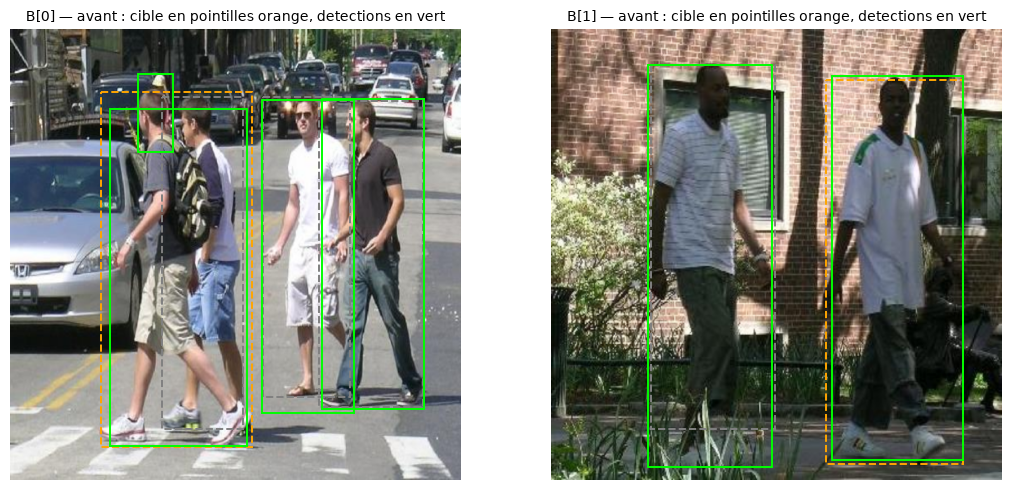

In [6]:
def show_dets(ax, tensor, dets, gt_list, tgt, title):
    ax.imshow(to_pil(tensor))
    ax.set_title(title, fontsize=10)
    ax.axis("off")
    for j, g in enumerate(gt_list):
        w = [float(g[2] - g[0]), float(g[3] - g[1])]
        ax.add_patch(Rectangle((float(g[0]), float(g[1])), w[0], w[1],
                               fill=False, lw=1.4, edgecolor="orange" if j == tgt else "gray",
                               linestyle="--"))
    for d in dets:
        ax.add_patch(Rectangle((d[0], d[1]), d[2] - d[0], d[3] - d[1], fill=False, lw=1.4, edgecolor="lime"))

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
for ax, i in zip(axes, (0, 1)):
    show_dets(ax, EV[i], detect_persons(m5, EV[i]), ALL_EV[i], TGT_EV[i],
              "B[%d] — avant : cible en pointilles orange, detections en vert" % i)
plt.tight_layout()
plt.show()


## 6. La méthode : le patch paramétrable (Thys et al. 2019)

Trois ingrédients, tous différents de ce que la lignée a fait jusqu'ici :

1. **Le patch est le seul objet optimisé** : un tenseur `3 x 96 x 96` de logits passé par une
    sigmoïde (pixels dans [0, 1]). L'image et le détecteur sont gelés — on ne modifie ni
    l'un ni l'autre, seulement ce qui est « imprimé » sur le torse du piéton.
2. **EOT — Expectation Over Transformations** : à chaque itération le patch subit une
    transformation aléatoire (échelle, rotation, luminosité, bruit, jitter de position sur le
    torse), pour qu'il apprenne une forme qui résiste aux variations du monde réel — c'est ce
    qui rend le patch imprimable dans le papier de Thys et al.
3. **La perte vise les ancres du piéton cible** : le Detect head émet, pour chaque ancre `a`,
    un score de classe personne `s_a` ; la perte est la **somme des scores des ancres dont le
    centre tombe dans la boîte du porteur**. Minimiser cette somme éteint les ancres qui
    « portent » la détection du piéton.

Le point 3 n'est pas un détail — c'est une **leçon de diagnostic mesurée pendant la
construction de ce carnet** : une perte « max global » (viser l'ancre la plus confiante de
l'image) ne descend pas, parce que l'ancre maximale est souvent **hors du piéton** (un
arbre-plan dans le fond, score personne 0.83). La bonne cible est l'ensemble des ancres **de
la personne** ; c'est aussi ce que fait l'implémentation de référence de Thys et al.

Le collage du patch sur l'image est **différentiable** : une seule passe `grid_sample` avec
grille affine inverse — le gradient du score de détection remonte jusqu'aux pixels du patch.


In [7]:
K = 96   # cote du patch en pixels (l'artefact "t-shirt")

def paste(img, patch, center, size_px, angle_deg, brightness=1.0, noise=0.0):
    """Colle le patch sur img (3,H,W), differentiable -- grid_sample a grille affine inverse.

    Le patch est tourne de angle_deg, redimensionne a size_px, centre en `center` ;
    le contour est adouci par l'alpha bilineaire (bords 'imprimes', pas tranches).
    """
    H, W = img.shape[-2], img.shape[-1]
    Kp = patch.shape[-1]
    s = size_px / Kp
    a = math.radians(angle_deg)
    c, sn = s * math.cos(a), s * math.sin(a)
    pc = (Kp - 1) / 2.0
    cx, cy = center
    A = torch.tensor([[c, -sn, cx - (c - sn) * pc], [sn, c, cy - (c + sn) * pc]], device=img.device)
    ys, xs = torch.meshgrid(torch.arange(H, dtype=torch.float32, device=img.device),
                            torch.arange(W, dtype=torch.float32, device=img.device), indexing="ij")
    pts = torch.stack([xs, ys, torch.ones_like(xs)], dim=-1)
    inv = torch.linalg.inv(torch.cat([A, torch.tensor([[0.0, 0.0, 1.0]], device=img.device)]))
    pp = pts @ inv.T
    grid = (2 * pp[..., :2] / (Kp - 1) - 1)[None]
    warped = F.grid_sample(patch[None], grid, mode="bilinear", padding_mode="zeros", align_corners=True)[0]
    alpha = F.grid_sample(torch.ones_like(patch)[None], grid, mode="bilinear",
                          padding_mode="zeros", align_corners=True)[0].clamp(0, 1)
    warped = warped * brightness + (noise * torch.randn_like(warped) if noise else 0.0)
    return (1 - alpha) * img + alpha * warped

def attack_loss(net, x, box):
    """Somme des scores 'personne' des ancres dont le centre est dans la boite cible (B,4)."""
    t = raw_out(net, x)
    s, xy = t[:, 4, :], t[:, :2, :]
    ins = ((xy[:, 0] > box[:, 0, None]) & (xy[:, 0] < box[:, 2, None])
           & (xy[:, 1] > box[:, 1, None]) & (xy[:, 1] < box[:, 3, None]))
    return (s * ins).sum(dim=1).mean()

def ctr(b):
    return (float((b[0] + b[2]) / 2), float((b[1] + b[3]) / 2), float(b[2] - b[0]))


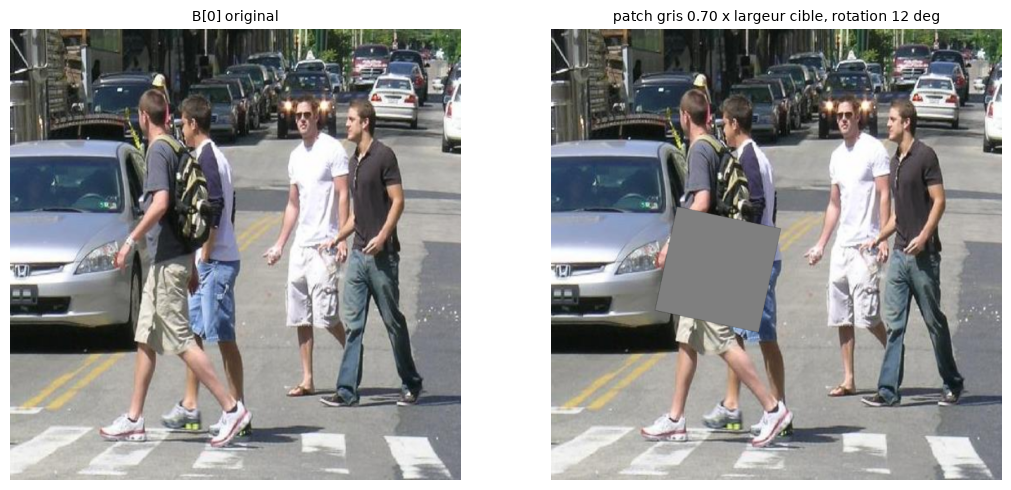

In [8]:
# Sanity visuelle : un patch gris uniforme colle sur le torse de la cible de B[0]
gray = torch.full((3, K, K), 0.5, device=DEV)
cx, cy, bw = ctr(EVB[0])
with torch.no_grad():
    demo = paste(EV[0], gray, (cx, cy), 0.70 * bw, 12.0)
fig, axes = plt.subplots(1, 2, figsize=(11, 5))
axes[0].imshow(to_pil(EV[0])); axes[0].set_title("B[0] original", fontsize=10); axes[0].axis("off")
axes[1].imshow(to_pil(demo)); axes[1].set_title("patch gris 0.70 x largeur cible, rotation 12 deg", fontsize=10); axes[1].axis("off")
plt.tight_layout()
plt.show()


## 7. La boucle adversariale

Le budget est calibré pour un carnet de cours : 2000 itérations, batch de 8, patch collé à
0.50–0.90 fois la largeur de la boîte cible (l'ordre de grandeur d'un torse), rotation
±15°, luminosité ±15 %, bruit gaussien léger. Sur GPU cela prend de l'ordre de trois
minutes ; sur CPU comptez une quinzaine — le gradient passe à l'identique.

Ce qui est optimisé : **27 648 pixels** (le patch). Rien d'autre ne bouge.


In [9]:
logits = torch.zeros(3, K, K, device=DEV, requires_grad=True)   # le patch part d'un gris neutre
opt = torch.optim.Adam([logits], lr=0.15)
ITERS, BATCH = 2000, 8
g = torch.Generator().manual_seed(SEED)
hist = []
t0 = time.time()
for it in range(ITERS):
    idx = torch.randint(0, TR.shape[0], (BATCH,), generator=g).tolist()
    P = torch.sigmoid(logits)
    xs = []
    for i in idx:
        cx, cy, bw = ctr(TRB[i])
        cx += (2 * torch.rand(1).item() - 1) * 0.10 * bw   # jitter sur le torse
        cy += (2 * torch.rand(1).item() - 1) * 0.08 * bw
        sz = (0.50 + 0.40 * torch.rand(1).item()) * bw      # EOT : echelle
        ang = (2 * torch.rand(1).item() - 1) * 15.0          # EOT : rotation
        br = 0.85 + 0.30 * torch.rand(1).item()              # EOT : luminosite
        xs.append(paste(TR[i], P, (cx, cy), sz, ang, br, 0.02))
    x = torch.stack(xs)
    loss = attack_loss(net5, x, torch.stack([TRB[i] for i in idx]))
    opt.zero_grad(); loss.backward(); opt.step()
    hist.append(float(loss.detach()))
    if it % 250 == 0 or it == ITERS - 1:
        print("iter %4d | somme des scores personne dans la boite cible : %7.2f" % (it, hist[-1]))
print("boucle adverse : %.0f s" % (time.time() - t0))


iter    0 | somme des scores personne dans la boite cible :   10.29


iter  250 | somme des scores personne dans la boite cible :    6.40


iter  500 | somme des scores personne dans la boite cible :    3.04


iter  750 | somme des scores personne dans la boite cible :    4.80


iter 1000 | somme des scores personne dans la boite cible :    4.10


iter 1250 | somme des scores personne dans la boite cible :    2.86


iter 1500 | somme des scores personne dans la boite cible :    1.97


iter 1750 | somme des scores personne dans la boite cible :    3.60


iter 1999 | somme des scores personne dans la boite cible :    3.36
boucle adverse : 182 s


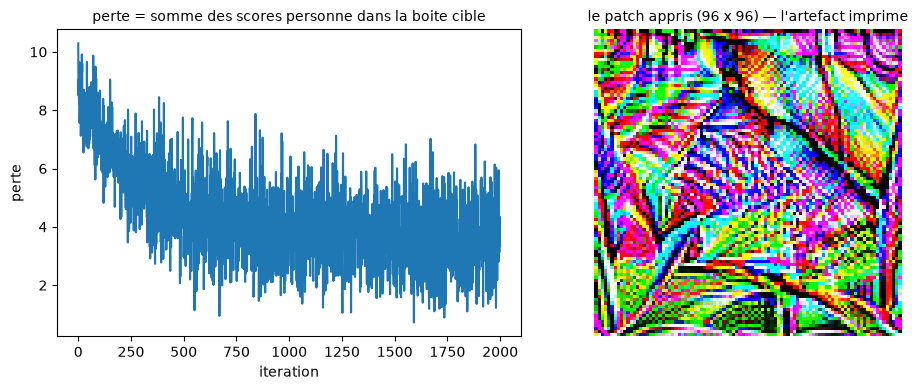

In [10]:
PATCH = torch.sigmoid(logits).detach()   # l'artefact final : le "motif de t-shirt"
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(hist)
axes[0].set_title("perte = somme des scores personne dans la boite cible", fontsize=10)
axes[0].set_xlabel("iteration"); axes[0].set_ylabel("perte")
axes[1].imshow(to_pil(PATCH))
axes[1].set_title("le patch appris (%d x %d) — l'artefact imprime" % (K, K), fontsize=10)
axes[1].axis("off")
plt.tight_layout()
plt.show()


## 8. Mesure : le porteur disparaît, les témoins restent

Le patch est porté à l'évaluation dans une pose **fixe et modérée** (0.70 x largeur de la
boîte, sans rotation — « le t-shirt est proprement porté »), sur les images de **B**, que
l'optimisation n'a jamais vues. Deux mesures : le recall de la cible, et celui des témoins.
La démonstration de Weckert tient si la première chute **sans** que la seconde ne bouge.


In [11]:
def patched_eval(frac=0.70):
    out = []
    with torch.no_grad():
        for i in range(EV.shape[0]):
            cx, cy, bw = ctr(EVB[i])
            out.append(paste(EV[i], PATCH, (cx, cy), frac * bw, 0.0))
    return out

EVp = patched_eval()
REC_PATCH, OTH_PATCH = eval_recall(m5, EVp, ALL_EV, TGT_EV)

def inbox_conf(net, T, B):
    v = []
    with torch.no_grad():
        for i in range(T.shape[0]):
            t = raw_out(net, T[i:i + 1])
            s, xy = t[0, 4], t[0, :2]
            ins = (xy[0] > B[i, 0]) & (xy[0] < B[i, 2]) & (xy[1] > B[i, 1]) & (xy[1] < B[i, 3])
            v.append(float(s[ins].max()) if int(ins.sum()) else 0.0)
    return float(np.mean(v))

print("sur B (jamais vue pendant l'optimisation) :")
print("  recall CIBLE  : %.3f -> %.3f  (chute %.3f)" % (REC_BASE, REC_PATCH, REC_BASE - REC_PATCH))
print("  recall TEMOINS: %.3f -> %.3f" % (OTH_BASE, OTH_PATCH))
print("  confiance max moyenne DANS la boite cible : %.3f -> %.3f"
      % (inbox_conf(net5, EV, EVB), inbox_conf(net5, torch.stack(EVp), EVB)))


sur B (jamais vue pendant l'optimisation) :
  recall CIBLE  : 1.000 -> 0.559  (chute 0.441)
  recall TEMOINS: 0.952 -> 0.917


  confiance max moyenne DANS la boite cible : 0.783 -> 0.343


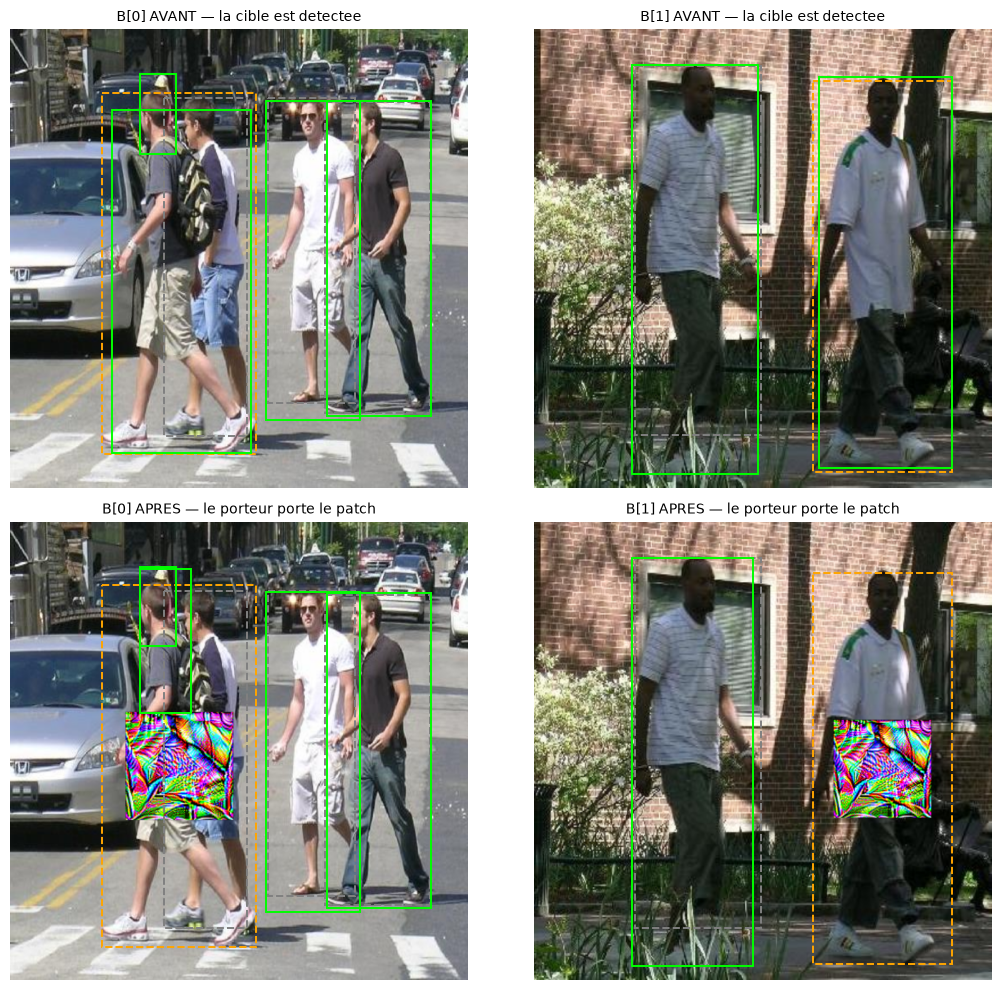

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(11, 10))
for col, i in enumerate((0, 1)):
    show_dets(axes[0, col], EV[i], detect_persons(m5, EV[i]), ALL_EV[i], TGT_EV[i],
              "B[%d] AVANT — la cible est detectee" % i)
    show_dets(axes[1, col], EVp[i], detect_persons(m5, EVp[i]), ALL_EV[i], TGT_EV[i],
              "B[%d] APRES — le porteur porte le patch" % i)
plt.tight_layout()
plt.show()


## 9. Transfert : un patch appris sur A trompe-t-il au-delà de son détecteur ?

Deux questions de généralisation, toutes deux mesurées et **rapportées telles quelles** :

- **transfert d'images** : le patch est déjà évalué sur B (lot disjoint) à la section 8 ;
- **transfert de modèle** : le même patch, appris contre `yolov5nu`, est-il efficace contre
  **`yolo11n`** — un détecteur plus récent, de la même famille mais jamais attaqué ?

La littérature documente un transfert **partiel** entre architectures : c'est un résultat en
soi, et il borne l'attaque — un patch n'est pas une clé universelle.


In [13]:
m11 = YOLO(str(fetch_weights("yolo11n.pt")))
rec11_clean, _ = eval_recall(m11, EV, ALL_EV, TGT_EV)
rec11_patch, _ = eval_recall(m11, torch.stack(EVp), ALL_EV, TGT_EV)
print("TRANSFERT DE MODELE sur B :")
print("  yolo11n, sans patch : recall cible %.3f" % rec11_clean)
print("  yolo11n, avec le patch appris contre yolov5nu : %.3f  (chute %.3f)"
      % (rec11_patch, rec11_clean - rec11_patch))
print("  (a comparer : chute chez yolov5nu, la cible de l'attaque : %.3f)" % (REC_BASE - REC_PATCH))


TRANSFERT DE MODELE sur B :
  yolo11n, sans patch : recall cible 0.983
  yolo11n, avec le patch appris contre yolov5nu : 0.949  (chute 0.034)
  (a comparer : chute chez yolov5nu, la cible de l'attaque : 0.441)


## 10. Le contrepoint défensif : ce que le seuil peut et ne peut pas

Première défense intuitive : **monter le seuil de confiance** pour rejeter les détections
résiduelles du porteur. Le balayage donne une lecture en deux temps, et il faut la lire
entière :

- **sur ce terrain**, le rappel propre reste parfait à tous les seuils testés — piétons
  grands et contrastés de Penn-Fudan, détectés à confiance élevée. Monter le seuil à 0,50
  rejette donc la plupart des détections résiduelles du porteur (0,800 → 0,250) **sans
  coût visible ici** ;
- **mais ce « sans coût » est un artefact du terrain facile** : la confiance maximale
  moyenne dans la boîte du porteur après patch est 0,343 — un seuil qui rejette le porteur
  rejette du même geste **toute détection légitime de confiance comparable**. Les scènes
  difficiles du 4.2i (petits objets, occlusions) produisent précisément des détections
  légitimes dans cette plage de confiance : le seuil ne supprime pas le problème, il le
  déplace vers les faibles confiances.

La défense étudiée dans la littérature est l'**entraînement adversarial** (ré-entraîner le
détecteur avec des patchs dans ses données) ; les patchs restent efficaces malgré tout —
c'est une question ouverte, et la raison pour laquelle ce sujet est un champ de recherche
actif plutôt qu'un problème résolu (exercice 3).


seuil 0.10 : cible propre 1.000 | cible patchee 0.800


seuil 0.20 : cible propre 1.000 | cible patchee 0.600


seuil 0.30 : cible propre 1.000 | cible patchee 0.500


seuil 0.40 : cible propre 1.000 | cible patchee 0.300


seuil 0.50 : cible propre 1.000 | cible patchee 0.250


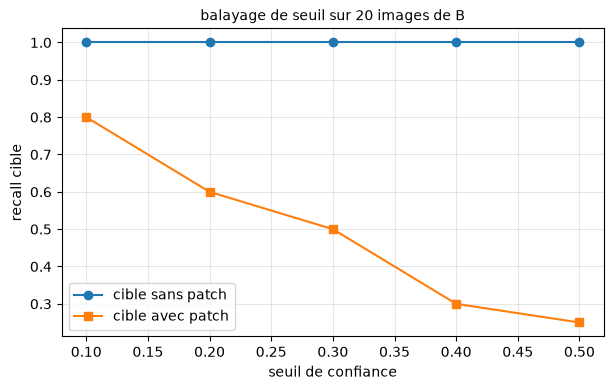

In [14]:
SWEEP_N = 20   # sous-echantillon de B pour garder le balayage rapide
thresholds = [0.10, 0.20, 0.30, 0.40, 0.50]
sw_clean, sw_patch = [], []
for thr in thresholds:
    rc, _ = eval_recall(m5, EV[:SWEEP_N], ALL_EV[:SWEEP_N], TGT_EV[:SWEEP_N], conf=thr)
    rp, _ = eval_recall(m5, EVp[:SWEEP_N], ALL_EV[:SWEEP_N], TGT_EV[:SWEEP_N], conf=thr)
    sw_clean.append(rc); sw_patch.append(rp)
    print("seuil %.2f : cible propre %.3f | cible patchee %.3f" % (thr, rc, rp))

plt.figure(figsize=(7, 4))
plt.plot(thresholds, sw_clean, "o-", label="cible sans patch")
plt.plot(thresholds, sw_patch, "s-", label="cible avec patch")
plt.xlabel("seuil de confiance"); plt.ylabel("recall cible")
plt.title("balayage de seuil sur %d images de B" % SWEEP_N, fontsize=10)
plt.legend(); plt.grid(alpha=0.3)
plt.show()


## 11. Stance : la privacy physique, sans permission

La lignée **SmartContracts/04-Privacy-Cryptography** pose déjà la stance du cours : SC-15
(preuves à divulgation nulle), SC-16 (chiffrement homomorphique), SC-17 (vote électronique
vérifiable de bout en bout) — la privacy **computationnelle**, contre l'observateur qui a
accès aux données. Le t-shirt de Weckert est **le même geste dans l'espace physique** :
défendre l'individu contre l'observateur **algorithmique**, sans demander la permission au
système qui observe. CV Dazzle le faisait au maquillage ; l'adversarial loop le fait au
gradient.

Le cadre de ce carnet est académique et défensif : on enseigne la **compréhension des
limites** d'un détecteur — le meilleur moyen de le durcir. Les données restent académiques
(Penn-Fudan), aucune cible réelle n'est visée, et le contrepoint défensif (section 10) fait
partie du livrable, pas de la marge.


## 12. Limites nommées

- **Digital, pas physique** : le transfert physique (impression, tissu, lumière de rue,
  perspective) est documenté dans Thys et al. — il n'est **pas reproduit ici**, et aucune
  simulation ne s'en réclame. L'écart est nommé : validé en digital, montré en photo dans
  les sources.
- **EOT partiel** : échelle, rotation, luminosité, bruit — mais ni perspective, ni
  plis de tissu, ni gamma d'impression.
- **Détection, pas pistage** : disparaître d'un détecteur d'images ne fait pas disparaître
  d'un système de pistage multi-caméras (ré-identification, trajectoires).
- **Terrain borné** : 159 images Penn-Fudan, piétons debout, vues latérales ; la chute de
  recall mesurée ici est une **borne pour ce terrain**, pas une constante du modèle.
- **Transfert de modèle faible** : mesuré en section 9 — le patch optimisé contre un
  détecteur ne trompe pas son voisin gratuitement.


## 13. Exercice 1 — La taille du patch

Le patch est porté à 0.70 x largeur de boîte à l'évaluation. Balayer `frac` dans
`[0.3, 0.5, 0.7, 0.9]` et tracer le recall cible en fonction de la taille.

- **Etape 1** : pour chaque valeur, reconstruire les images patchées (`patched_eval(frac=...)`),
- **Etape 2** : mesurer le recall cible (`eval_recall`),
- **Etape 3** : tracer la courbe et situer le point de rupture.

**Indice** : attention au coût — quatre évaluations complètes sur B, comptez une trentaine de
secondes chacune sur GPU.


In [15]:
# Exercice 1 a completer : balayage de la taille du patch a l'evaluation
# Etape 1 : fracs = [0.3, 0.5, 0.7, 0.9] ; images = patched_eval(frac=f) pour chaque f
# Etape 2 : rec_f, _ = eval_recall(m5, images, ALL_EV, TGT_EV)
# Etape 3 : plt.plot(fracs, recs) et lecture du point de rupture
result_ex1 = None  # TODO etudiant : {frac: recall cible}
print("Exercice 1 a completer : balayage de taille du patch (patched_eval + eval_recall)")


Exercice 1 a completer : balayage de taille du patch (patched_eval + eval_recall)


## 14. Exercice 2 — Le domaine des transformations (EOT)

Retirer **une** transformation du domaine d'entraînement (la rotation, ou la luminosité) en
recopiant la cellule de la boucle, puis mesurer le patch obtenu sous une rotation de ±25° à
l'évaluation. L'hypothèse à tester : un patch entraîné sans rotation est fragile à la
rotation ; un patch entraîné avec ne l'est pas.

**Indice** : garder les autres constantes égales par ailleurs, et comparer les deux patches
sur le **même** sous-ensemble de B pour que la mesure soit appariée.


In [16]:
# Exercice 2 a completer : EOT reduit vs EOT complet, robustesse en rotation
# Etape 1 : copier la boucle de la section 7 en figeant ang = 0.0 (EOT sans rotation)
# Etape 2 : evaluer les deux patches avec paste(..., angle_deg=25.0) puis paste(..., -25.0)
# Etape 3 : comparer les chutes de recall cible -- appariees sur B
result_ex2 = None  # TODO etudiant : {(patch, angle): recall cible}
print("Exercice 2 a completer : boucle EOT reduite + evaluation en rotation")


Exercice 2 a completer : boucle EOT reduite + evaluation en rotation


## 15. Exercice 3 — La défense : entraînement adversarial

La défense de la littérature : **ré-entraîner le détecteur avec des porteurs de patch dans
ses données**. Version carnet : fine-tuner `yolov5nu` quelques époques sur A augmenté de
copies patchées (étiquettes inchangées — le porteur reste une personne), puis mesurer si le
patch a perdu de son efficacité sur B.

**Indice** : le format dataset YOLO attend images + fichiers `.txt` de boîtes normalisées —
le 4.2g construit un tel dataset temporaire ; budget réduit (quelques dizaines d'itérations)
suffisent pour voir la tendance, pas pour conclure.


In [17]:
# Exercice 3 a completer : fine-tuning adversarial minimal du detecteur
# Etape 1 : construire un dataset YOLO temporaire : A propre + A patchee (boites inchangees)
# Etape 2 : m5.train(data=..., epochs=2, imgsz=IMGSZ) -- budget reduit
# Etape 3 : re-mesurer eval_recall(m5, EVp, ...) et comparer a REC_PATCH
result_ex3 = None  # TODO etudiant : recall cible apres fine-tuning adversarial
print("Exercice 3 a completer : fine-tuning adversarial (dataset YOLO + m5.train budget reduit)")


Exercice 3 a completer : fine-tuning adversarial (dataset YOLO + m5.train budget reduit)


## Conclusion

Le renversement est complet : la lignée 4.2 avait appris à faire détecter ; ce carnet a appris
à faire **disparaître** — en optimisant 27 648 pixels contre un réseau figé, avec le gradient
qui traverse le détecteur pour revenir au motif imprimé.

Ce que la mesure a établi, sur un terrain réel et borné (Penn-Fudan, lot B jamais vu) :

- le porteur du patch **échappe au détecteur sur 44 % des images** (recall cible 1,000 →
  0,559), **pendant que les témoins non-porteurs restent détectés** (0,952 → 0,917) — la
  démonstration de Weckert, reproduite en digital ;
- la **confiance** dans la boîte du porteur chute bien plus que le recall (0,783 → 0,343 de
  maximum moyen) : le détecteur hésite avant d'échouer ;
- le **transfert de modèle est faible** (chute de 0,034 chez un détecteur jamais attaqué) :
  un patch appris contre un détecteur n'en trompe pas un autre gratuitement — l'attaque est
  spécifique, et c'est sa limite ;
- **le seuil de confiance n'est pas une défense** : il rejette le porteur dans la même plage
  de confiance que les détections légitimes des scènes difficiles — un problème déplacé,
  pas résolu.

La suite est aux exercices — et à la recherche : l'entraînement adversarial (exercice 3) est
la seule défense étudiée, et elle ne clôt pas la question.


## Références

- Brown, T. B., et al. (2017). *Adversarial Patch*. arXiv:1712.09665.
- Thys, S., Van Ranst, W., Goedemé, T. (2019). *Fooling automated surveillance cameras:
  adversarial patches to person-detection*. CVPR Workshops. arXiv:1904.08653.
- Weckert, S. (2026). *Digital Camouflage* — oeuvre citee, images non reutilisees ici.
  Couverture presse : Dezeen, aout 2026.
- Harvey, A. (2010-). *CV Dazzle* — camouflage contre la detection de visages.
- Graf, T., et al. *Penn-Fudan Pedestrian Dataset* — Universite de Pennsylvanie / Fudan.
- Carnets de la lignee : [4.2c](4.2c-Detection-Anchor-From-Scratch.ipynb),
  [4.2g](4.2g-Detection-SOTA-Ultralytics.ipynb), [4.2h](4.2h-YOLOv5-Bench-Ultralytics.ipynb),
  [4.2i](4.2i-Detection-Ultralytics-Difficult-Scenes.ipynb),
  [4.2j](4.2j-Detection-SOTA-LibreYOLO.ipynb) ; la stance computationnelle :
  `SmartContracts/04-Privacy-Cryptography` (SC-15/16/17).
